In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from engine import Value
from nn import Neuron, Layer, MLP

In [4]:
# seed 
np.random.seed(1337)
random.seed(1337)

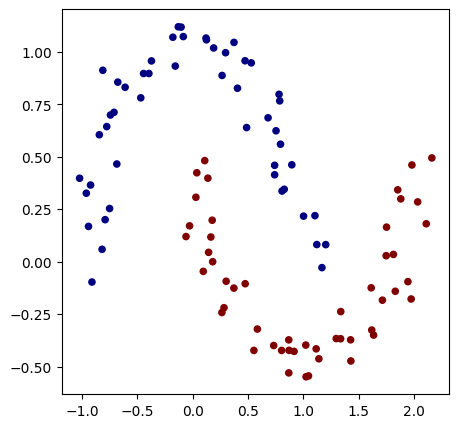

In [5]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(
    n_samples=100, 
    noise=0.1)

y = y*2 - 1 # convert labels to be either -1 or 1

# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [6]:
# initialize a model 

# 2 inputs, 2 hidden layers (16 neurons each), 1 output
model = MLP(2, [16, 16, 1]) # 2-layer neural network

print(model)
print("number of parameters", len(model.parameters()))

number of parameters 337


In [17]:
# Forward pass:
# Run the model on every sample, then calculate mean squared error.
def mse_loss(model, X, y):
    predictions = [model(x) for x in X]

    loss = sum(
        (prediction - target) ** 2
        for prediction, target in zip(predictions, y)
    ) / len(y)

    return loss


# Backtracking line search using the Armijo condition.
def find_learning_rate(
    model,
    X,
    y,
    current_loss,
    initial_lr=1.0,
    shrink_factor=0.5,
    armijo_constant=1e-4,
    max_steps=10
):
    parameters = model.parameters()

    # Save the parameter values at the current point.
    original_values = [parameter.data for parameter in parameters]

    # These gradients must already have been calculated by loss.backward().
    gradients = [parameter.grad for parameter in parameters]

    # ||grad L||^2
    gradient_norm_squared = sum(
        gradient ** 2
        for gradient in gradients
    )

    # A zero gradient means there is no steepest-descent direction.
    # It does not necessarily prove that we are at a local minimum.
    if gradient_norm_squared == 0:
        return 0.0

    learning_rate = initial_lr

    for step in range(max_steps):
        # Temporarily try:
        # parameter_new = parameter_old - learning_rate * gradient
        for parameter, original, gradient in zip(
            parameters,
            original_values,
            gradients
        ):
            parameter.data = original - learning_rate * gradient

        # Forward pass using the temporary parameter values.
        candidate_loss = mse_loss(model, X, y)

        # Armijo sufficient-decrease requirement.
        required_loss = (
            current_loss
            - armijo_constant
            * learning_rate
            * gradient_norm_squared
        )

        accepted = candidate_loss.data <= required_loss

        # Restore the original parameters because this function
        # only searches for a learning rate.
        for parameter, original in zip(parameters, original_values):
            parameter.data = original

        if accepted:
            return learning_rate

        # Candidate was too large, so try a smaller step.
        learning_rate *= shrink_factor

    return 0.0

In [22]:
model = MLP(2, [4, 4, 1])

epochs = 500

for epoch in range(epochs):

    # --------------------------------
    # 1. Forward pass
    # --------------------------------
    loss = mse_loss(model, X, y)

    # --------------------------------
    # 2. Clear previous gradients
    # --------------------------------
    for parameter in model.parameters():
        parameter.grad = 0.0

    # --------------------------------
    # 3. Backward pass
    # --------------------------------
    loss.backward()

    # --------------------------------
    # 4. Find a learning rate
    # --------------------------------
    learning_rate = find_learning_rate(
        model=model,
        X=X,
        y=y,
        current_loss=loss.data,
        initial_lr= 1.0,
        shrink_factor=0.5,
        armijo_constant=1e-4,
        max_steps=8
    )

    # --------------------------------
    # 5. Permanently update parameters
    # --------------------------------
    for parameter in model.parameters():
        parameter.data -= (
            learning_rate * parameter.grad
        )

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Loss: {loss.data:.6f} | "
            f"Learning rate: {learning_rate:.6f}"
        )

Epoch   0 | Loss: 1.672402 | Learning rate: 1.000000
Epoch  10 | Loss: 0.386418 | Learning rate: 0.500000
Epoch  20 | Loss: 0.365049 | Learning rate: 0.500000
Epoch  30 | Loss: 0.363810 | Learning rate: 0.500000
Epoch  40 | Loss: 0.362766 | Learning rate: 1.000000
Epoch  50 | Loss: 0.361982 | Learning rate: 0.500000
Epoch  60 | Loss: 0.361309 | Learning rate: 0.500000
Epoch  70 | Loss: 0.360762 | Learning rate: 0.500000
Epoch  80 | Loss: 0.360204 | Learning rate: 1.000000
Epoch  90 | Loss: 0.359747 | Learning rate: 0.500000
Epoch 100 | Loss: 0.359324 | Learning rate: 0.500000
Epoch 110 | Loss: 0.358985 | Learning rate: 0.500000
Epoch 120 | Loss: 0.358515 | Learning rate: 0.500000
Epoch 130 | Loss: 0.358049 | Learning rate: 0.500000
Epoch 140 | Loss: 0.357682 | Learning rate: 0.500000
Epoch 150 | Loss: 0.357318 | Learning rate: 0.250000
Epoch 160 | Loss: 0.356845 | Learning rate: 1.000000
Epoch 170 | Loss: 0.356428 | Learning rate: 0.500000
Epoch 180 | Loss: 0.356089 | Learning rate: 0.

(-1.548639298268643, 1.951360701731357)

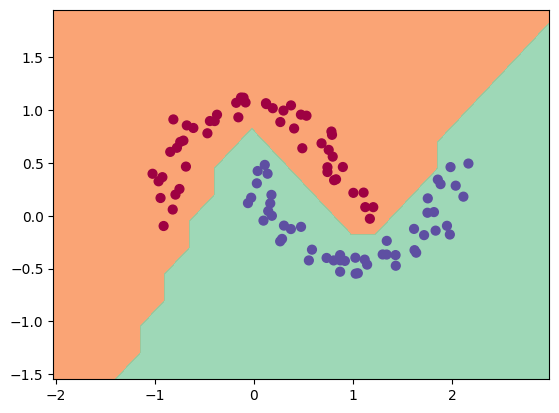

In [23]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
